# Time Series Analysis: Sales Trends Over Time
This notebook analyzes temporal patterns in our sales data to identify trends, seasonality, and peak performance periods.
We'll examine daily, monthly, and weekly patterns to understand when our business performs best and inform strategic planning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

## 1. Data Preparation
Loading the raw Amazon sales dataset.

In [2]:
df = pd.read_csv('../data/amazon_sale_report.csv', low_memory=False)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 2. Feature Selection
Selecting relevant columns for time series analysis and creating a focused dataset.

In [3]:
# Keep only the relevant columns
columns_to_keep = [
    'Date',
    'Status',
    'Amount',
    'Qty'
]

time_series_df = df[columns_to_keep].copy()

time_series_df.info()
time_series_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    128975 non-null  str    
 1   Status  128975 non-null  str    
 2   Amount  121180 non-null  float64
 3   Qty     128975 non-null  int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 3.9 MB


,Date,Status,Amount,Qty
0,04-30-22,Cancelled,647.62,0
1,04-30-22,Shipped - Delivered to Buyer,406.00,1
2,04-30-22,Shipped,329.00,1
3,04-30-22,Cancelled,753.33,0
4,04-30-22,Shipped,574.00,1


## 3. Data Preprocessing
Cleaning and preparing the dataset for time series analysis by handling data quality issues and standardizing formats.
- Standardize column names by removing whitespace
- Filter out cancelled orders and non-transactional records
- Remove records with missing values in critical fields
- Convert Date column to proper datetime format for time-based analysis
- Extract temporal components (year, month, week, day of week)
- Ensure consistent data types for analysis readiness

In [4]:
# Remove whitespace from column names
df.columns = df.columns.str.strip()

# Filter for actual shipped orders
shipped_statuses = [
    'Shipped',
    'Shipped - Delivered to Buyer',
    'Shipped - Picked Up',
    'Shipped - Out for Delivery'
]

is_shipped = time_series_df['Status'].isin(shipped_statuses)
time_series_df = time_series_df[is_shipped].copy()

# Remove rows with missing values
time_series_df.dropna(subset=['Amount', 'Date'], inplace=True)

# Convert Date from string to proper datetime object
time_series_df['Date'] = pd.to_datetime(time_series_df['Date'], format='%m-%d-%y')

# Sort by date
time_series_df = time_series_df.sort_values('Date')

# Extract time components
time_series_df['Year'] = time_series_df['Date'].dt.year
time_series_df['Month'] = time_series_df['Date'].dt.month
time_series_df['MonthName'] = time_series_df['Date'].dt.month_name()
time_series_df['Week'] = time_series_df['Date'].dt.isocalendar().week
time_series_df['DayOfWeek'] = time_series_df['Date'].dt.day_name()
time_series_df['DayOfWeekNum'] = time_series_df['Date'].dt.dayofweek

time_series_df.info()
time_series_df.head()

<class 'pandas.DataFrame'>
Index: 107365 entries, 48969 to 91838
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          107365 non-null  datetime64[us]
 1   Status        107365 non-null  str           
 2   Amount        107365 non-null  float64       
 3   Qty           107365 non-null  int64         
 4   Year          107365 non-null  int32         
 5   Month         107365 non-null  int32         
 6   MonthName     107365 non-null  str           
 7   Week          107365 non-null  UInt32        
 8   DayOfWeek     107365 non-null  str           
 9   DayOfWeekNum  107365 non-null  int32         
dtypes: UInt32(1), datetime64[us](1), float64(1), int32(3), int64(1), str(3)
memory usage: 7.5 MB


,Date,Status,Amount,Qty,Year,Month,MonthName,Week,DayOfWeek,DayOfWeekNum
48969,2022-03-31,Shipped,481.0,1,2022,3,March,13,Thursday,3
48998,2022-03-31,Shipped,698.0,1,2022,3,March,13,Thursday,3
48999,2022-03-31,Shipped - Delivered to Buyer,248.0,1,2022,3,March,13,Thursday,3
49000,2022-03-31,Shipped,322.0,1,2022,3,March,13,Thursday,3
49001,2022-03-31,Shipped,599.0,1,2022,3,March,13,Thursday,3


## 4. Daily Sales Trends Analysis
Analyzing daily revenue and order volume patterns to identify short-term trends and anomalies.

In [5]:
# Aggregate daily sales
daily_sales = time_series_df.groupby('Date').agg({
    'Amount': 'sum',
    'Qty': 'sum'
}).reset_index()

daily_sales['OrderCount'] = time_series_df.groupby('Date').size().values

print(f"Date Range: {daily_sales['Date'].min()} to {daily_sales['Date'].max()}")
print(f"Total Days: {len(daily_sales)}")
print(f"\nDaily Statistics:")
print(daily_sales[['Amount', 'Qty', 'OrderCount']].describe())

Date Range: 2022-03-31 00:00:00 to 2022-06-29 00:00:00
Total Days: 91

Daily Statistics:
             Amount          Qty   OrderCount
count  9.100000e+01    91.000000    91.000000
mean   7.655307e+05  1184.054945  1179.835165
std    1.561431e+05   262.566451   261.291930
min    9.418300e+04   151.000000   151.000000
25%    6.950060e+05  1035.000000  1032.000000
50%    7.752800e+05  1195.000000  1194.000000
75%    8.597300e+05  1336.500000  1333.500000
max    1.094989e+06  1755.000000  1745.000000


/tmp/ipykernel_77979/3381707581.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


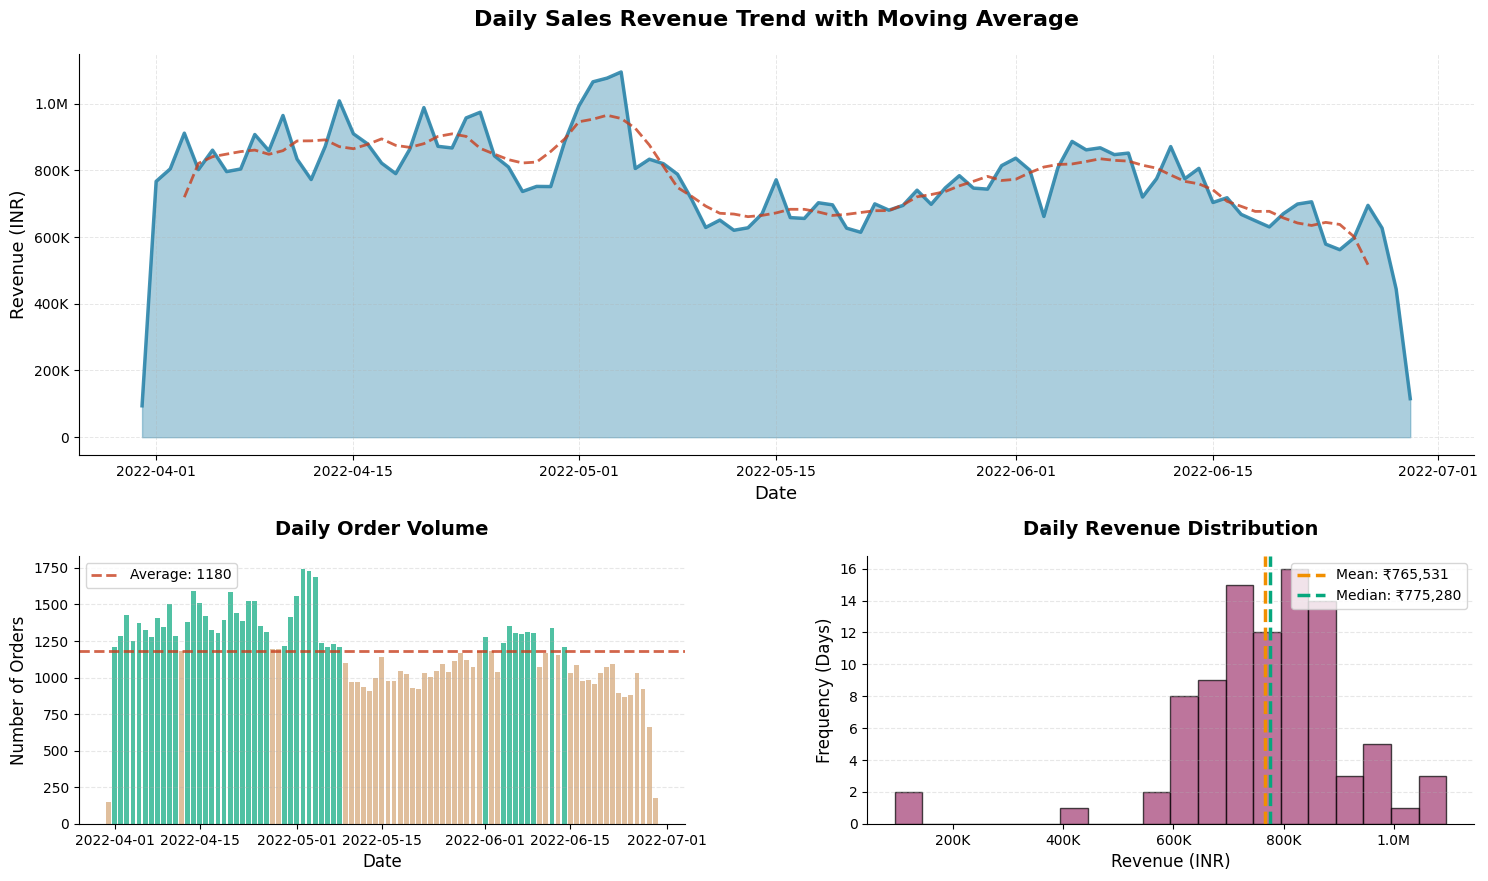

In [6]:
# Money formatter
def money_format(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    else:
        return f"{x:.0f}"

formatter = FuncFormatter(money_format)

# Create a more impressive visualization with gradient and annotations
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], hspace=0.3, wspace=0.3)

# Main revenue trend with gradient fill
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(daily_sales['Date'], daily_sales['Amount'], linewidth=2.5, color='#2E86AB', alpha=0.9, zorder=3)
ax1.fill_between(daily_sales['Date'], daily_sales['Amount'], alpha=0.4, color='#2E86AB')

# Add 7-day moving average
daily_sales['MA7'] = daily_sales['Amount'].rolling(window=7, center=True).mean()
ax1.plot(daily_sales['Date'], daily_sales['MA7'], linewidth=2, color='#C73E1D', 
         linestyle='--', alpha=0.8, label='7-Day Moving Average', zorder=4)

ax1.set_title('Daily Sales Revenue Trend with Moving Average', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Date', fontsize=13)
ax1.set_ylabel('Revenue (INR)', fontsize=13)
ax1.yaxis.set_major_formatter(formatter)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Order count with bar chart
ax2 = fig.add_subplot(gs[1, 0])
colors = ['#06A77D' if val > daily_sales['OrderCount'].median() else '#D4A574' 
          for val in daily_sales['OrderCount']]
ax2.bar(daily_sales['Date'], daily_sales['OrderCount'], color=colors, alpha=0.7, edgecolor='none')
ax2.axhline(y=daily_sales['OrderCount'].mean(), color='#C73E1D', linestyle='--', 
            linewidth=2, alpha=0.8, label=f'Average: {daily_sales["OrderCount"].mean():.0f}')
ax2.set_title('Daily Order Volume', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Orders', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper left', fontsize=10)

# Revenue distribution histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(daily_sales['Amount'], bins=20, color='#A23B72', alpha=0.7, edgecolor='black')
ax3.axvline(x=daily_sales['Amount'].mean(), color='#F18F01', linestyle='--', 
            linewidth=2.5, label=f'Mean: ₹{daily_sales["Amount"].mean():,.0f}')
ax3.axvline(x=daily_sales['Amount'].median(), color='#06A77D', linestyle='--', 
            linewidth=2.5, label=f'Median: ₹{daily_sales["Amount"].median():,.0f}')
ax3.set_title('Daily Revenue Distribution', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Revenue (INR)', fontsize=12)
ax3.set_ylabel('Frequency (Days)', fontsize=12)
ax3.xaxis.set_major_formatter(formatter)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('../images/02_time_series_analysis/daily_sales_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Monthly Sales Performance Analysis
Examining monthly revenue patterns and trends to understand seasonal variations and long-term performance.

In [7]:
# Aggregate monthly sales
monthly_sales = time_series_df.groupby(['Year', 'Month', 'MonthName']).agg({
    'Amount': 'sum',
    'Qty': 'sum'
}).reset_index()

monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

print("Monthly Sales Summary:")
print(monthly_sales[['YearMonth', 'Amount', 'Qty']])

Monthly Sales Summary:
  YearMonth      Amount    Qty
0   2022-03     94183.0    151
1   2022-04  25668848.0  41094
2   2022-05  23465763.0  35487
3   2022-06  20434499.0  31017


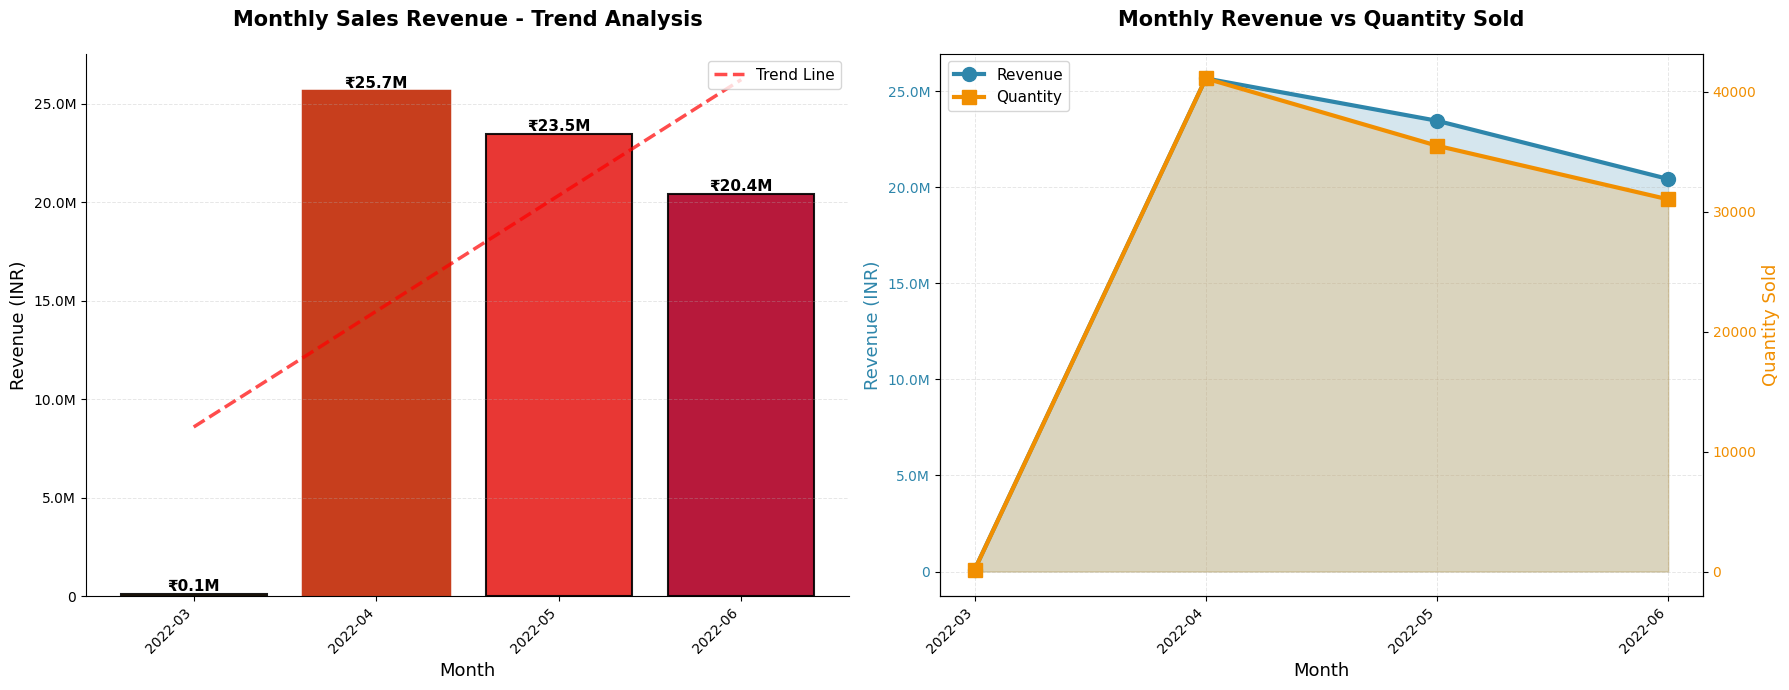

In [8]:
# Create an impressive monthly sales visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Monthly revenue with gradient bars
months = monthly_sales['YearMonth']
revenues = monthly_sales['Amount']
quantities = monthly_sales['Qty']

# Create gradient effect with different shades
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(months)))
bars = ax1.bar(months, revenues, color=colors, edgecolor='black', linewidth=1.5, alpha=0.9)

# Add value labels on bars
for i, (month, revenue) in enumerate(zip(months, revenues)):
    ax1.text(i, revenue, f'₹{revenue/1_000_000:.1f}M', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight the best month
best_month_idx = revenues.idxmax()
bars[best_month_idx].set_color('#C73E1D')
bars[best_month_idx].set_alpha(1.0)
bars[best_month_idx].set_linewidth(2.5)

ax1.set_title('Monthly Sales Revenue - Trend Analysis', fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel('Month', fontsize=13)
ax1.set_ylabel('Revenue (INR)', fontsize=13)
ax1.yaxis.set_major_formatter(formatter)
plt.sca(ax1)
plt.xticks(rotation=45, ha='right')
ax1.grid(True, alpha=0.3, linestyle='--', axis='y', linewidth=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add trend line
z = np.polyfit(range(len(months)), revenues, 1)
p = np.poly1d(z)
ax1.plot(range(len(months)), p(range(len(months))), "r--", 
         linewidth=2.5, alpha=0.7, label='Trend Line')
ax1.legend(loc='upper right', fontsize=11)

# Monthly quantity with dual-axis comparison
ax2_twin = ax2.twinx()

# Revenue line
line1 = ax2.plot(months, revenues, marker='o', linewidth=3, markersize=10, 
                 color='#2E86AB', label='Revenue', zorder=3)
ax2.fill_between(range(len(months)), revenues, alpha=0.2, color='#2E86AB')

# Quantity line
line2 = ax2_twin.plot(months, quantities, marker='s', linewidth=3, markersize=10, 
                      color='#F18F01', label='Quantity', zorder=3)
ax2_twin.fill_between(range(len(months)), quantities, alpha=0.2, color='#F18F01')

ax2.set_title('Monthly Revenue vs Quantity Sold', fontsize=15, fontweight='bold', pad=20)
ax2.set_xlabel('Month', fontsize=13)
ax2.set_ylabel('Revenue (INR)', fontsize=13, color='#2E86AB')
ax2_twin.set_ylabel('Quantity Sold', fontsize=13, color='#F18F01')
ax2.yaxis.set_major_formatter(formatter)
ax2.tick_params(axis='y', labelcolor='#2E86AB')
ax2_twin.tick_params(axis='y', labelcolor='#F18F01')
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax2.spines['top'].set_visible(False)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('../images/02_time_series_analysis/monthly_sales_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Day of Week Performance Analysis
Understanding sales patterns across different days of the week to optimize weekly operational strategies.

In [9]:
# Aggregate by day of week
dow_sales = time_series_df.groupby(['DayOfWeekNum', 'DayOfWeek']).agg({
    'Amount': 'sum',
    'Qty': 'sum'
}).reset_index()

dow_sales = dow_sales.sort_values('DayOfWeekNum')
dow_sales['AvgDailyRevenue'] = dow_sales['Amount'] / len(daily_sales['Date'].dt.dayofweek.value_counts())

print("Day of Week Performance:")
print(dow_sales[['DayOfWeek', 'Amount', 'Qty', 'AvgDailyRevenue']])

Day of Week Performance:
   DayOfWeek      Amount    Qty  AvgDailyRevenue
0     Monday  10065297.0  15567     1.437900e+06
1    Tuesday   9994389.0  15470     1.427770e+06
2  Wednesday   9791557.0  15211     1.398794e+06
3   Thursday   9300855.0  14398     1.328694e+06
4     Friday   9649978.0  14894     1.378568e+06
5   Saturday  10105734.0  15632     1.443676e+06
6     Sunday  10755483.0  16577     1.536498e+06
